# Krisha.kz  Предсказание цены квартиры

Обучаем модель на 7,000 объявлениях о продаже квартир по Казахстану.  
**Цель:** предсказать цену квартиры по её характеристикам.  
**Финальная модель:** XGBoost + log transform → R² 0.872, CV R² 0.900

## 1. Загрузка данных

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('krisha_final.csv')
print(df.shape)
df.head()

(7000, 25)


,url,заголовок,комнаты,цена,город,flat.building,house.year,flat.floor,live.square,flat.toilet,...,flat.flooring,ceiling,flat.priv_dorm,has_change,описание,flat.renovation,flat.balcony_g,flat.phone,flat.security,map.complex
0,https://krisha.kz/a/show/1011510961,"2-комнатная квартира · 54.5 м² · 8/9 этаж, Мкр...",2,25000000,"Семей, Красный Кордон",кирпичный,2021,8 из 9,"54.5 м², Площадь кухни — 9.3 м²",совмещенный,...,линолеум,2.5 м,нет,Нет,Продается 2х комнатная квартира в Карагайлы на...,NaN,NaN,NaN,NaN,NaN
1,https://krisha.kz/a/show/1009096504,"3-комнатная квартира · 58 м² · 2/9 этаж, Есенб...",3,24000000,"Астана, Сарыарка р-н",кирпичный,1971,2 из 9,58 м²,совмещенный,...,линолеум,2.7 м,нет,Нет,"Пластиковые окна, комнаты изолированы.\n\n🏡 По...","не новый, но аккуратный ремонт",да,нет,"домофон, видеонаблюдение",NaN
2,https://krisha.kz/a/show/1012115818,"3-комнатная квартира · 73 м² · 2/10 этаж, ул. ...",3,51999999,"Астана, Алматы р-н",кирпичный,2021,2 из 10,73 м²,совмещенный,...,ламинат,3 м,нет,Нет,"Улучшенная, комнаты изолированы, встроенная ку...",NaN,NaN,NaN,"сигнализация, видеонаблюдение, видеодомофон",Salem
3,https://krisha.kz/a/show/1011429295,"3-комнатная квартира · 90 м² · 19/23 этаж, Айн...",3,51000000,"Астана, Сарайшык р-н",монолитный,2021,19 из 23,90 м²,раздельный,...,ламинат,2.9 м,нет,Нет,🔥🔥🔥СРОЧНО Продам 3-х Комнатную квартиру в ЖК С...,свежий ремонт,NaN,блокиратор,NaN,Сенатор Park
4,https://krisha.kz/a/show/1006437195,"3-комнатная квартира · 73 м² · 1/5 этаж, 10 ле...",3,25000000,"Каскелен, Алматинская обл.",кирпичный,1988,1 из 5,73 м²,раздельный,...,ламинат,2.6 м,нет,Нет,"Кладовка, удобно под коммерцию.\n\nСрочно! 3ко...",NaN,да,NaN,"решетки на окнах, домофон, видеонаблюдение",NaN


## 2. Первичный анализ

In [5]:
print(df.dtypes)
print()
print(df.isnull().sum())

url                object
заголовок          object
комнаты             int64
цена                int64
город              object
flat.building      object
house.year          int64
flat.floor         object
live.square        object
flat.toilet        object
flat.balcony       object
flat.door          object
inet.type          object
flat.parking       object
live.furniture     object
flat.flooring      object
ceiling            object
flat.priv_dorm     object
has_change         object
описание           object
flat.renovation    object
flat.balcony_g     object
flat.phone         object
flat.security      object
map.complex        object
dtype: object

url                   0
заголовок             0
комнаты               0
цена                  0
город                 0
flat.building       565
house.year            0
flat.floor          493
live.square           0
flat.toilet        1762
flat.balcony       3215
flat.door          3026
inet.type          4153
flat.parking       3160

In [6]:
# стиль визуалов 
BG       = '#0d0d0d'
AXES_BG  = '#1a1814'
GRID_CLR = '#2e2a20'
TEXT_CLR = '#f5f0e8'
# градиент
VOLCANIC = ['#c0392b', '#a93226', '#922b21',
             '#7b241c', '#641e16', '#4d1813', '#36110e']


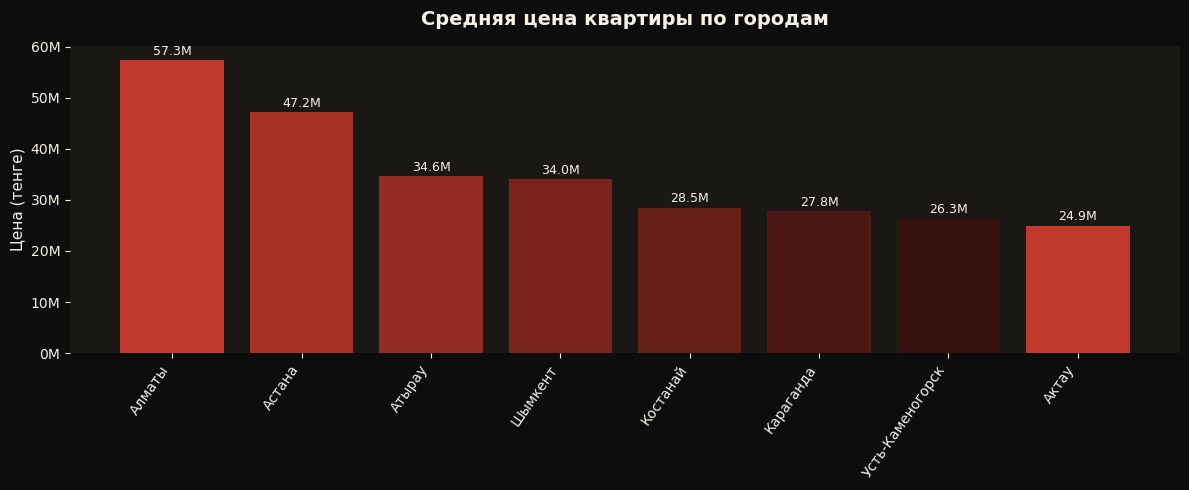

In [7]:
# Визуал 1, средняя цена по городам
город_temp = df['город'].str.split(',').str[0].str.strip()
топ_города = ['Алматы', 'Астана', 'Шымкент', 'Караганда',
              'Актау', 'Атырау', 'Усть-Каменогорск', 'Костанай']
маска = город_temp.isin(топ_города)
цена_город = df[маска].groupby(город_temp[маска])['цена'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(AXES_BG)

bar_colors = VOLCANIC[:len(цена_город)]
bars = ax.bar(цена_город.index, цена_город.values, color=bar_colors)

ax.set_title('Средняя цена квартиры по городам', fontsize=14,
             fontweight='bold', color=TEXT_CLR, pad=15)
ax.set_ylabel('Цена (тенге)', fontsize=11, color=TEXT_CLR)
ax.tick_params(colors=TEXT_CLR)
ax.spines[:].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.0f}М'))
ax.set_facecolor(AXES_BG)
ax.yaxis.label.set_color(TEXT_CLR)
ax.xaxis.label.set_color(TEXT_CLR)
plt.xticks(rotation=55, ha='right', color=TEXT_CLR)
plt.yticks(color=TEXT_CLR)

for bar, val in zip(bars, цена_город.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500_000,
            f'{val/1_000_000:.1f}М', ha='center', va='bottom',
            fontsize=9, color=TEXT_CLR)

plt.tight_layout()
plt.show()


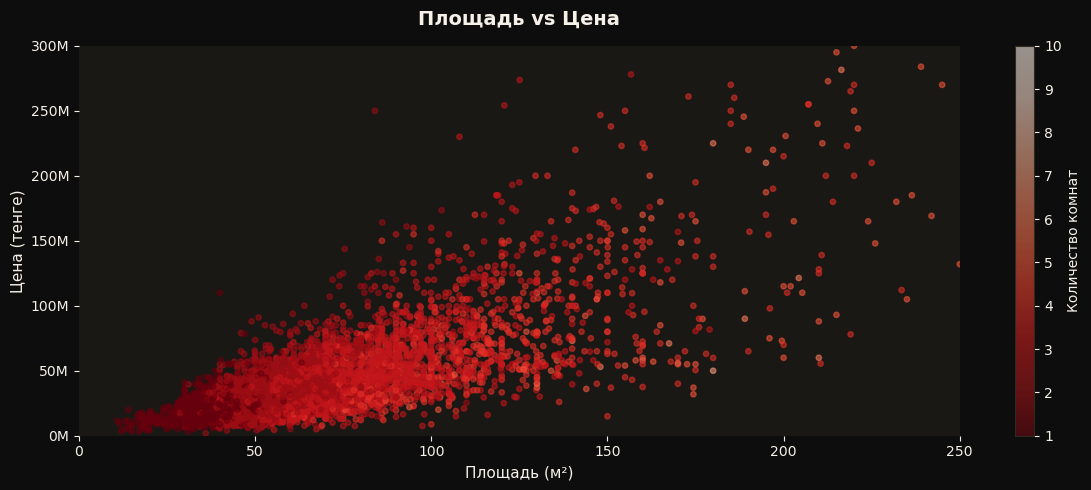

In [8]:
# Визуал 2,  площадь vs цена
площадь_temp = df['live.square'].str.extract(r'([\d.]+)').astype(float)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(AXES_BG)

scatter = ax.scatter(площадь_temp, df['цена'],
                     c=df['комнаты'], cmap='Reds_r',
                     alpha=0.55, s=15)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Количество комнат', color=TEXT_CLR, fontsize=10)
cbar.ax.yaxis.set_tick_params(color=TEXT_CLR)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT_CLR)
cbar.outline.set_edgecolor(GRID_CLR)
cbar.ax.set_facecolor(AXES_BG)

ax.set_title('Площадь vs Цена', fontsize=14, fontweight='bold',
             color=TEXT_CLR, pad=15)
ax.set_xlabel('Площадь (м²)', fontsize=11, color=TEXT_CLR)
ax.set_ylabel('Цена (тенге)', fontsize=11, color=TEXT_CLR)
ax.tick_params(colors=TEXT_CLR)
ax.spines[:].set_visible(False)
ax.set_xlim(0, 250)
ax.set_ylim(0, 300_000_000)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.0f}М'))
plt.yticks(color=TEXT_CLR)
plt.xticks(color=TEXT_CLR)

plt.tight_layout()
plt.show()


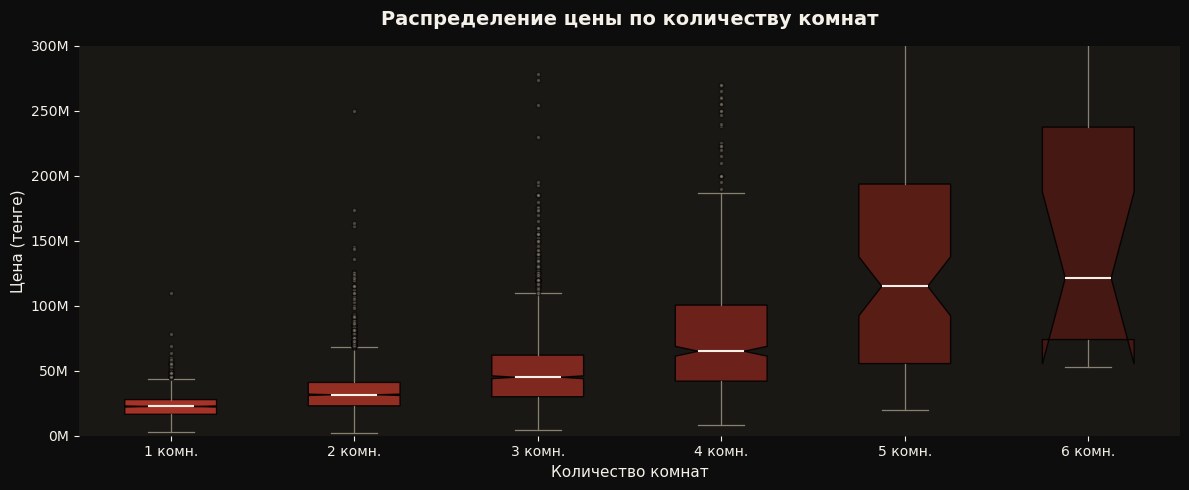

In [9]:
# Визуал 3, цена по количеству комнат
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(AXES_BG)

data = [df[df['комнаты'] == k]['цена'].values for k in range(1, 7)]
bp = ax.boxplot(data, tick_labels=[f'{k} комн.' for k in range(1, 7)],
                patch_artist=True, notch=True)

for patch, color in zip(bp['boxes'], VOLCANIC):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for element in ['whiskers', 'caps']:
    plt.setp(bp[element], color='#888070', linewidth=0.9)
plt.setp(bp['medians'], color=TEXT_CLR, linewidth=1.5)
plt.setp(bp['fliers'], markerfacecolor='#888070', markersize=3, alpha=0.5)

ax.set_title('Распределение цены по количеству комнат', fontsize=14,
             fontweight='bold', color=TEXT_CLR, pad=15)
ax.set_ylabel('Цена (тенге)', fontsize=11, color=TEXT_CLR)
ax.set_xlabel('Количество комнат', fontsize=11, color=TEXT_CLR)
ax.tick_params(colors=TEXT_CLR)
ax.spines[:].set_visible(False)
ax.set_ylim(0, 300_000_000)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.0f}М'))
plt.yticks(color=TEXT_CLR)
plt.xticks(color=TEXT_CLR)

plt.tight_layout()
plt.show()


## 3. Удаление лишних колонок

Убираем колонки с пропусками >50% и нерелевантные для ML.

In [11]:
threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=threshold)
df = df.drop(columns=['url', 'заголовок', 'описание'])

print(df.shape)
print(df.columns.tolist())

(7000, 19)
['комнаты', 'цена', 'город', 'flat.building', 'house.year', 'flat.floor', 'live.square', 'flat.toilet', 'flat.balcony', 'flat.door', 'flat.parking', 'live.furniture', 'flat.flooring', 'ceiling', 'flat.priv_dorm', 'has_change', 'flat.renovation', 'flat.security', 'map.complex']


## 4. Уникальные значения по колонкам

In [13]:
for col in df.columns:
    print(f'\n{col}: {df[col].nunique()} уникальных')
    print(df[col].value_counts().head(5))


комнаты: 9 уникальных
комнаты
2    2698
3    2106
1    1489
4     591
5      91
Name: count, dtype: int64

цена: 1398 уникальных
цена
25000000    108
35000000     98
23000000     89
28000000     88
45000000     87
Name: count, dtype: int64

город: 275 уникальных
город
Астана, Есильский р-н        674
Астана, Нура р-н             598
Алматы, Бостандыкский р-н    473
Алматы, Алатауский р-н       353
Астана, Алматы р-н           352
Name: count, dtype: int64

flat.building: 4 уникальных
flat.building
монолитный    3347
кирпичный     2003
панельный     1007
иной            78
Name: count, dtype: int64

house.year: 82 уникальных
house.year
2025    822
2026    670
2024    441
2023    402
2022    370
Name: count, dtype: int64

flat.floor: 317 уникальных
flat.floor
4 из 5    368
5 из 5    357
3 из 5    280
1 из 5    265
2 из 5    244
Name: count, dtype: int64

live.square: 3628 уникальных
live.square
40 м²    70
50 м²    69
70 м²    69
60 м²    64
45 м²    57
Name: count, dtype: int64

flat.t

## 5. Feature engineering

- `город` и `район` разбиваем на две отдельные колонки
- `flat.floor` → `этаж` и `всего_этажей`
- `live.square`, `ceiling` → числа
- `flat.security` → количество систем безопасности

In [15]:
df['район'] = df['город'].str.split(',').str[1].str.strip()
df['город'] = df['город'].str.split(',').str[0].str.strip()

df[['этаж', 'всего_этажей']] = df['flat.floor'].str.extract(r'(\d+) из (\d+)').astype(float)
df = df.drop(columns=['flat.floor'])

df['площадь'] = df['live.square'].str.extract(r'([\d.]+)').astype(float)
df = df.drop(columns=['live.square'])

df['высота_потолков'] = df['ceiling'].str.extract(r'([\d.]+)').astype(float)
df = df.drop(columns=['ceiling'])

df['безопасность'] = df['flat.security'].str.split(',').str.len().fillna(0).astype(int)
df = df.drop(columns=['flat.security', 'map.complex'])

print(df.shape)
print(df.isnull().sum())

(7000, 20)
комнаты               0
цена                  0
город                 0
flat.building       565
house.year            0
flat.toilet        1762
flat.balcony       3215
flat.door          3026
flat.parking       3160
live.furniture     2760
flat.flooring      3202
flat.priv_dorm     1006
has_change          454
flat.renovation    3380
район               144
этаж                673
всего_этажей        673
площадь               0
высота_потолков     895
безопасность          0
dtype: int64


## 6. Train/Test split и заполнение пропусков

Сначала делаем split, только потом считаем медианы, чтобы не было leakage.

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['цена'])
y = df['цена']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = ['этаж', 'всего_этажей', 'высота_потолков']
for col in num_cols:
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)

cat_cols = ['flat.building', 'flat.toilet', 'flat.balcony', 'flat.door',
            'flat.parking', 'live.furniture', 'flat.flooring', 'flat.priv_dorm',
            'has_change', 'flat.renovation', 'район']
for col in cat_cols:
    X_train[col] = X_train[col].fillna('неизвестно')
    X_test[col] = X_test[col].fillna('неизвестно')

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(X_train.isnull().sum())

Train: (5600, 19), Test: (1400, 19)
комнаты            0
город              0
flat.building      0
house.year         0
flat.toilet        0
flat.balcony       0
flat.door          0
flat.parking       0
live.furniture     0
flat.flooring      0
flat.priv_dorm     0
has_change         0
flat.renovation    0
район              0
этаж               0
всего_этажей       0
площадь            0
высота_потолков    0
безопасность       0
dtype: int64


## 7. Кодирование категориальных признаков

Используем **XGBoost native categories** вместо LabelEncoding.  
XGBoost сам находит оптимальные сплиты по категориям, без искусственного порядка,  
который LabelEncoder вносит там, где его нет (тип ремонта, тип балкона и т.д.).


In [19]:
# XGBoost native categories - конвертируем в dtype 'category'
# Никаких числовых кодов вручную - XGBoost сам обрабатывает.

cat_encode_cols = ['город', 'район', 'flat.building', 'flat.toilet', 'flat.balcony',
                   'flat.door', 'flat.parking', 'live.furniture', 'flat.flooring',
                   'flat.priv_dorm', 'has_change', 'flat.renovation']

for col in cat_encode_cols:
    # Объединяем категории train+test чтобы test не имел unseen categories
    all_cats = pd.Categorical(
        pd.concat([X_train[col], X_test[col]]).unique()
    ).categories
    X_train[col] = pd.Categorical(X_train[col], categories=all_cats)
    X_test[col]  = pd.Categorical(X_test[col],  categories=all_cats)

print('Типы данных после кодирования:')
print(X_train.dtypes)
print()
print(f'Пример: город — {X_train["город"].cat.categories[:5].tolist()}')
X_train.head()


Типы данных после кодирования:
комнаты               int64
город              category
flat.building      category
house.year            int64
flat.toilet        category
flat.balcony       category
flat.door          category
flat.parking       category
live.furniture     category
flat.flooring      category
flat.priv_dorm     category
has_change         category
flat.renovation    category
район              category
этаж                float64
всего_этажей        float64
площадь             float64
высота_потолков     float64
безопасность          int64
dtype: object

Пример: город — ['Абай', 'Абай обл.', 'Акколь', 'Акмол', 'Акмолинская обл.']


,комнаты,город,flat.building,house.year,flat.toilet,flat.balcony,flat.door,flat.parking,live.furniture,flat.flooring,flat.priv_dorm,has_change,flat.renovation,район,этаж,всего_этажей,площадь,высота_потолков,безопасность
1032,4,Караганда,неизвестно,2023,2 с/у и более,лоджия,металлическая,паркинг,полностью,ламинат,нет,Нет,неизвестно,Казыбек би р-н,6.0,9.0,98.0,3.0,5
6339,3,Астана,монолитный,2016,совмещенный,лоджия,металлическая,рядом охраняемая стоянка,полностью,паркет,нет,Нет,"не новый, но аккуратный ремонт",р-н Байконур,4.0,21.0,86.3,2.7,2
3886,2,Астана,кирпичный,2022,совмещенный,лоджия,неизвестно,неизвестно,полностью,ламинат,нет,Да,"не новый, но аккуратный ремонт",Нура р-н,8.0,12.0,45.3,3.0,0
2653,2,Актау,неизвестно,2023,неизвестно,неизвестно,неизвестно,неизвестно,неизвестно,неизвестно,неизвестно,Нет,неизвестно,18-й мкр,3.0,6.0,65.0,2.8,0
6914,3,Алматы,монолитный,2009,2 с/у и более,неизвестно,металлическая,паркинг,полностью,неизвестно,нет,Нет,неизвестно,Бостандыкский р-н,3.0,16.0,86.0,3.0,0


## 8. Распределение целевой переменной

Цена имеет длинный правый хвост - применим log transform для улучшения качества модели.

count    7.000000e+03
mean     4.301131e+07
std      4.077108e+07
min      1.800000e+06
25%      2.300000e+07
50%      3.300000e+07
75%      4.923938e+07
max      9.709000e+08
Name: цена, dtype: float64


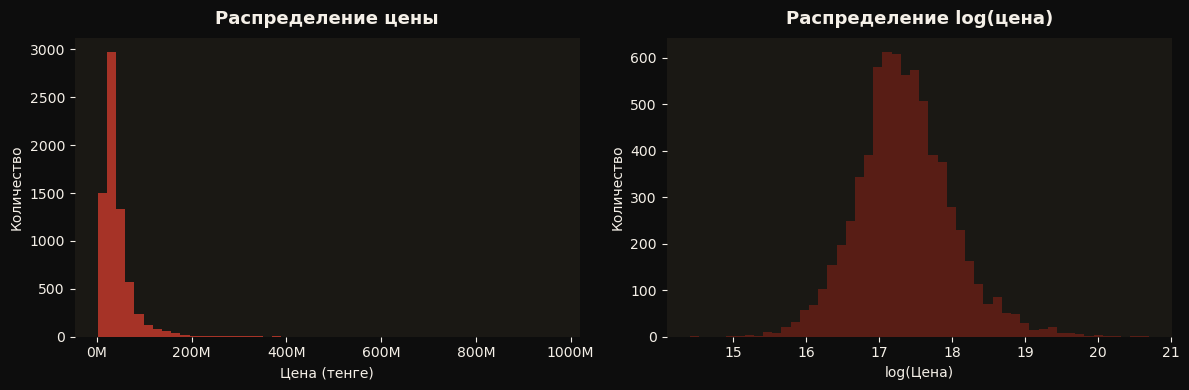

In [21]:
print(y.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(AXES_BG)
    ax.spines[:].set_visible(False)
    ax.tick_params(colors=TEXT_CLR)

axes[0].hist(y, bins=50, color='#c0392b', alpha=0.85, edgecolor='none')
axes[0].set_title('Распределение цены', fontsize=13, fontweight='bold',
                  color=TEXT_CLR, pad=10)
axes[0].set_xlabel('Цена (тенге)', fontsize=10, color=TEXT_CLR)
axes[0].set_ylabel('Количество', fontsize=10, color=TEXT_CLR)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.0f}М'))
plt.setp(axes[0].get_xticklabels(), color=TEXT_CLR)
plt.setp(axes[0].get_yticklabels(), color=TEXT_CLR)

axes[1].hist(np.log1p(y), bins=50, color='#641e16', alpha=0.85, edgecolor='none')
axes[1].set_title('Распределение log(цена)', fontsize=13, fontweight='bold',
                  color=TEXT_CLR, pad=10)
axes[1].set_xlabel('log(Цена)', fontsize=10, color=TEXT_CLR)
axes[1].set_ylabel('Количество', fontsize=10, color=TEXT_CLR)
plt.setp(axes[1].get_xticklabels(), color=TEXT_CLR)
plt.setp(axes[1].get_yticklabels(), color=TEXT_CLR)

plt.tight_layout()
plt.show()


## 9. Обучение моделей

### Random forest (baseline)

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OrdinalEncoder

# RF не поддерживает category dtype — делаем числовое кодирование только для RF
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_rf = X_train.copy()
X_test_rf  = X_test.copy()
X_train_rf[cat_encode_cols] = oe.fit_transform(X_train[cat_encode_cols].astype(str))
X_test_rf[cat_encode_cols]  = oe.transform(X_test[cat_encode_cols].astype(str))

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_train)
y_pred_rf = rf.predict(X_test_rf)

print('Random Forest (OrdinalEncoder)')
print(f'MAE: {mean_absolute_error(y_test, y_pred_rf):,.0f} тенге')
print(f'R²:  {r2_score(y_test, y_pred_rf):.3f}')


Random Forest (OrdinalEncoder)
MAE: 8,656,302 тенге
R²:  0.799


### XGBoost базовый

In [25]:
from xgboost import XGBRegressor

xgb_base = XGBRegressor(n_estimators=100, random_state=42,
                         enable_categorical=True, tree_method='hist')
xgb_base.fit(X_train, y_train)
y_pred_xgb = xgb_base.predict(X_test)

print('XGBoost базовый (native categories)')
print(f'MAE: {mean_absolute_error(y_test, y_pred_xgb):,.0f} тенге')
print(f'R²:  {r2_score(y_test, y_pred_xgb):.3f}')


XGBoost базовый (native categories)
MAE: 7,954,046 тенге
R²:  0.842


### XGBoost с подбором параметров

In [27]:
xgb_tuned = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical=True,
    tree_method='hist',
)
xgb_tuned.fit(X_train, y_train)
y_pred_tuned = xgb_tuned.predict(X_test)

print('XGBoost tuned (native categories)')
print(f'MAE: {mean_absolute_error(y_test, y_pred_tuned):,.0f} тенге')
print(f'R²:  {r2_score(y_test, y_pred_tuned):.3f}')


XGBoost tuned (native categories)
MAE: 7,527,912 тенге
R²:  0.861


### XGBoost + log transform

Log transform сжимает выбросы - модель лучше обучается на скошенных данных.

In [29]:
y_train_log = np.log1p(y_train)

xgb_log = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical=True,
    tree_method='hist',
)
xgb_log.fit(X_train, y_train_log)
y_pred_log = np.expm1(xgb_log.predict(X_test))

print('XGBoost + log transform (native categories)')
print(f'MAE: {mean_absolute_error(y_test, y_pred_log):,.0f} тенге')
print(f'R²:  {r2_score(y_test, y_pred_log):.3f}')


XGBoost + log transform (native categories)
MAE: 7,050,796 тенге
R²:  0.872


### XGBoost финальный

In [31]:
xgb_final = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    enable_categorical=True,
    tree_method='hist',
)
xgb_final.fit(X_train, y_train_log)
y_pred_final = np.expm1(xgb_final.predict(X_test))

print('XGBoost финальный (native categories)')
print(f'MAE: {mean_absolute_error(y_test, y_pred_final):,.0f} тенге')
print(f'R²:  {r2_score(y_test, y_pred_final):.3f}')


XGBoost финальный (native categories)
MAE: 6,911,874 тенге
R²:  0.872


## 10. Важность признаков

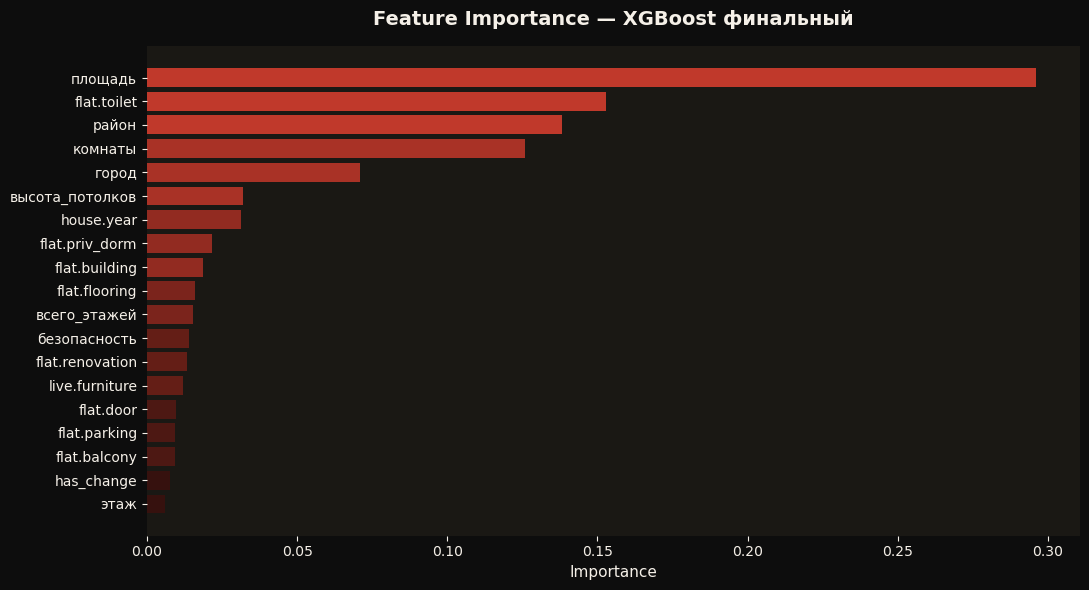

площадь            0.295921
flat.toilet        0.152942
район              0.138278
комнаты            0.125918
город              0.071023
высота_потолков    0.032072
house.year         0.031233
flat.priv_dorm     0.021554
flat.building      0.018613
flat.flooring      0.015834
всего_этажей       0.015269
безопасность       0.013949
flat.renovation    0.013430
live.furniture     0.012023
flat.door          0.009595
flat.parking       0.009454
flat.balcony       0.009232
has_change         0.007689
этаж               0.005971
dtype: float32


In [33]:
feat_imp = pd.Series(xgb_final.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(AXES_BG)

# Градиент по значимости: топ — ярче, остальные — темнее
n = len(feat_imp)
bar_clrs = [VOLCANIC[min(i * len(VOLCANIC) // n, len(VOLCANIC)-1)] for i in range(n)]
ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color=bar_clrs[::-1])

ax.set_title('Feature Importance — XGBoost финальный', fontsize=14,
             fontweight='bold', color=TEXT_CLR, pad=15)
ax.set_xlabel('Importance', fontsize=11, color=TEXT_CLR)
ax.tick_params(colors=TEXT_CLR)
ax.spines[:].set_visible(False)
plt.yticks(color=TEXT_CLR)
plt.xticks(color=TEXT_CLR)

plt.tight_layout()
plt.show()

print(feat_imp)


## 11. Cross-validation

Проверяем стабильность модели  результат не должен зависеть от конкретной разбивки.

In [35]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_final, X_train, y_train_log, cv=5, scoring='r2')

print(f'R² по фолдам: {scores.round(3)}')
print(f'Среднее R²:   {scores.mean():.3f} ± {scores.std():.3f}')

R² по фолдам: [0.896 0.909 0.895 0.898 0.901]
Среднее R²:   0.900 ± 0.005


## 12. Сохранение модели

In [37]:
import joblib

# Сохраняем модель
joblib.dump(xgb_final, 'xgb_model.pkl')

# Сохраняем словарь: колонка → список категорий (не просто названия колонок!)
cat_categories = {col: X_train[col].cat.categories.tolist() for col in cat_encode_cols}
joblib.dump(cat_categories, 'cat_categories.pkl')

# Добавить к joblib.dump
train_medians = {col: X_train[col].median() for col in ['этаж', 'всего_этажей', 'высота_потолков']}
joblib.dump(train_medians, 'train_medians.pkl')

print('Модель сохранена!')
print(f'Колонок-категорий: {len(cat_categories)}')

Модель сохранена!
Колонок-категорий: 12
